In [54]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import torchvision.datasets as datasets
from torchvision import models, transforms
from torchvision.utils import save_image, make_grid
from torch.optim.lr_scheduler import StepLR
from torch import autograd
from torch.autograd import Variable
from tensorboardX import SummaryWriter

from typing import Dict, Tuple
from tqdm import tqdm
import numpy as np
import time
import os
import random
from tabulate import tabulate

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

%matplotlib inline

if __name__ == "__main__":
    print("Torch version:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.device_count() > 0 else "No GPU detected")



Torch version: 2.7.0+cu126
CUDA available: True
CUDA version: 12.6
Number of GPUs: 1
GPU name: NVIDIA GeForce RTX 4090


In [55]:
from waveguide_dataset_paired import WaveguideDatasetPaired
dataset = WaveguideDatasetPaired('train_test_split.h5')

In [56]:
class Flatten(nn.Module):
    def forward(self, x):
        return torch.flatten(x, 1)

In [57]:
class Net4_ModeWeight4(nn.Module):
    """
    Net4 variant that predicts:
    - the first 4 modes and weights → output shape [B, 4, 2]
    Uses GroupNorm instead of BatchNorm.
    """
    def __init__(self):
        super().__init__()

        def groupnorm_2d(channels, num_groups=8):
            return nn.GroupNorm(num_groups=num_groups, num_channels=channels)

        def groupnorm_1d(features, num_groups=8):
            return nn.GroupNorm(num_groups=num_groups, num_channels=features)

        # ---------- CNN trunk ----------
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1),
            groupnorm_2d(64), nn.GELU(),

            nn.Conv2d(64, 128, 3, 1, 1),
            groupnorm_2d(128), nn.GELU(),

            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, 1, 1),
            groupnorm_2d(256), nn.GELU(),

            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(256, 512, 3, 1, 1),
            groupnorm_2d(512), nn.GELU(),

            nn.MaxPool2d(2), nn.Dropout(0.25),

            Flatten()  # -> [B, 8192]
        )

        # ---------- Fully-connected head ----------
        self.fc = nn.Sequential(
            nn.Linear(8192 + 4, 2048),
            groupnorm_1d(2048), nn.GELU(), nn.Dropout(0.4),

            nn.Linear(2048, 1024),
            groupnorm_1d(1024), nn.GELU(), nn.Dropout(0.3),

            nn.Linear(1024, 256),
            groupnorm_1d(256), nn.GELU(), nn.Dropout(0.25),

            nn.Linear(256, 8)  # 4 (mode, weight) pairs → 4 × 2 = 8
        )

    def forward(self, x_img, x_cond):
        x = self.cnn(x_img)                   # [B, 8192]
        x = torch.cat((x, x_cond), dim=1)     # [B, 8196]
        x = self.fc(x)                        # [B, 8]
        return x.view(-1, 4, 2)               # [B, 4, 2]


In [58]:
def train_structured(model, device, loader, optimizer, loss_fn):
    """
    Train for one epoch on structured [4,2] mode-weight inputs.

    · model takes:   waveguide, params
    · model outputs: [B, 4, 2] (4 mode-weight pairs)
    · target:        cond[:, :4, :] (mode-weight targets)
    """
    model.train()

    for cond, params, waveguide in loader:
        cond, params, waveguide = (
            cond.to(device),       # [B, 4, 2]
            params.to(device),     # [B, 4]
            waveguide.to(device),  # [B, 1, 32, 32]
        )

        y_true = cond  # shape [B, 4, 2]

        optimizer.zero_grad()
        y_pred = model(waveguide, params)  # shape [B, 4, 2]
        loss = loss_fn(y_pred, y_true)
        loss.backward()
        optimizer.step()


In [60]:
def test_structured(model, device, loader, loss_fn, dataset, epoch_num, total_epochs):
    """
    Evaluate model for one epoch using [B, 4, 2] structured mode-weight targets.

    * Model outputs:   [B, 4, 2] (4 mode-weight pairs)
    * Ground truth:    [B, 4, 2]

    Returns
    -------
    float
        Average MSE loss over the test set.
    """
    model.eval()
    total_loss = 0.0
    collected  = []

    # scalar stats for inverse normalization
    mode_mean_log = float(dataset.meanm[0])
    mode_std_log  = float(dataset.stdm[0])
    wt_mean_log   = float(dataset.meanw[0])
    wt_std_log    = float(dataset.stdw[0])

    with torch.no_grad():
        for cond, params, waveguide in loader:
            cond, params, waveguide = (
                cond.to(device),       # [B, 4, 2]
                params.to(device),     # [B, 4]
                waveguide.to(device),  # [B, 1, 32, 32]
            )

            y_true = cond              # [B, 4, 2]
            y_pred = model(waveguide, params)  # [B, 4, 2]
            batch_loss = loss_fn(y_pred, y_true).item()
            total_loss += batch_loss * waveguide.size(0)

            for t, o, p in zip(y_true.cpu(), y_pred.cpu(), params.cpu()):
                if len(collected) < 50:
                    # Denormalize all 4 mode-weight pairs
                    t_modes = np.expm1(t[:, 0].numpy() * mode_std_log + mode_mean_log)
                    t_weights = np.expm1(t[:, 1].numpy() * wt_std_log + wt_mean_log)
                    o_modes = np.expm1(o[:, 0].numpy() * mode_std_log + mode_mean_log)
                    o_weights = np.expm1(o[:, 1].numpy() * wt_std_log + wt_mean_log)

                    collected.append((
                        np.stack([t_modes, t_weights], axis=1),   # [4, 2]
                        np.stack([o_modes, o_weights], axis=1),   # [4, 2]
                        p.numpy()
                    ))

    avg_loss = total_loss / len(loader.dataset)

    # Plot on last epoch
    if epoch_num == total_epochs - 1 and collected:
        chosen = random.sample(collected, 4)  # fewer samples for clarity

        fig, axes = plt.subplots(4, 2, figsize=(10, 10), sharex=True)
        fig.suptitle("Targets (red) vs Outputs (blue) for 4 samples")

        for i, (tgt, out, _) in enumerate(chosen):
            for j in range(4):
                axes[j][0].plot([i], [tgt[j, 0]], 'ro')
                axes[j][0].plot([i], [out[j, 0]], 'bx')
                axes[j][1].plot([i], [tgt[j, 1]], 'ro')
                axes[j][1].plot([i], [out[j, 1]], 'bx')

        for j in range(4):
            axes[j][0].set_ylabel(f"Mode {j}")
            axes[j][1].set_ylabel(f"Weight {j}")
            for ax in axes[j]:
                ax.grid(True)
                ax.set_xticks(range(len(chosen)))
                ax.set_xticklabels([f"Sample {i}" for i in range(len(chosen))])

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    return avg_loss


Training, loss: 0.0256: 100%|█████████▉| 199/200 [3:27:12<01:01, 61.49s/it]  

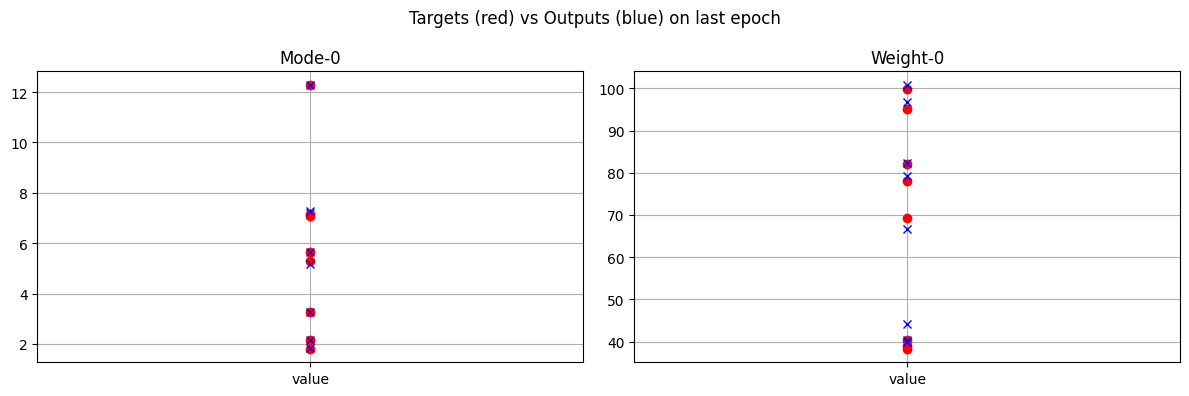

Training, loss: 0.0256: 100%|██████████| 200/200 [3:28:13<00:00, 62.47s/it]


In [61]:
def main(dataset):
    import os
    os.makedirs("models", exist_ok=True)

    # Hyperparameters
    batch_size = 512
    test_batch_size = 1000
    lr = 1e-3
    gamma = 0.9
    epochs = 200
    save_dir = 'predict_top4_mode_weight'  # updated name
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Model and optimizer
    model = Net4_ModeWeight4().to(device)  # updated model
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    loss_fn = nn.MSELoss()

    # Train/test split
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
    test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False, num_workers=8)

    e_loss_graph = []

    # Training loop with tqdm
    pbar = tqdm(range(epochs), desc="Training")

    for epoch in pbar:
        train_structured(model, device, train_loader, optimizer, loss_fn)
        e_loss = test_structured(model, device, test_loader, loss_fn, dataset, epoch, epochs)
        e_loss_graph.append(e_loss)

        # Update tqdm description
        pbar.set_description(f"Epoch {epoch+1}/{epochs} | Test Loss: {e_loss:.4f}")

        scheduler.step()

        # Save model checkpoint
        torch.save(model.state_dict(), f'models/{save_dir}.pth')

        # Save plot
        plt.figure()
        plt.plot(range(1, epoch + 2), e_loss_graph, label='Test Loss')
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Test Loss per Epoch ({save_dir})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"models/{save_dir}.png")
        plt.close()

if __name__ == '__main__':
    main(dataset)
